In [1]:
from typing import Any, List, Tuple, Dict
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import h5py
from torch.utils.data import DataLoader

from model.dataset import ToxDataset
from model.model_architecture import MLP

In [2]:
kw_0800 = pd.read_csv("../benchmark/all_tox.tsv", sep="\t")

kw_0800['Protein families'] = kw_0800['Protein families'].str.split(';').str[0]
kw_0800['Protein families'] = kw_0800['Protein families'].str.split(',').str[0]

kw_0800['Protein families'] = kw_0800['Protein families'].replace('I1 superfamily', 'Conotoxin I1 superfamily')
kw_0800['Protein families'] = kw_0800['Protein families'].replace('O1 superfamily', 'Conotoxin O1 superfamily')
kw_0800['Protein families'] = kw_0800['Protein families'].replace('O2 superfamily', 'Conotoxin O2 superfamily')
kw_0800['Protein families'] = kw_0800['Protein families'].replace('E superfamily', 'Conotoxin E superfamily')
kw_0800['Protein families'] = kw_0800['Protein families'].replace('F superfamily', 'Conotoxin F superfamily')

mapping = {
    r'Conotoxin.*': 'Conotoxin family',
    r'Neurotoxin.*': 'Neurotoxin family',
    r'Scoloptoxin.*|Scolopendra.*': 'Scoloptoxin family',
    r'Caterpillar.*': 'Caterpillar family',
    r'Teretoxin.*': 'Teretoxin family',
    r'Limacoditoxin.*': 'Limacoditoxin family',
    r'Scutigerotoxin.*': 'Scutigerotoxin family',
    r'Cationic peptide.*': 'Cationic peptide family',
    r'Formicidae venom.*': 'Formicidae venom family',
    r'Bradykinin-potentiating peptide family|Natriuretic peptide family|Natriuretic': 'Natriuretic, Bradykinin potentiating peptide family',
    r'.*phospholipase.*|.*Phospholipase.*': 'Phospholipase family'
}

# Apply mapping
for pattern, replacement in mapping.items():
    kw_0800['Protein families'] = kw_0800['Protein families'].str.replace(pattern, replacement, regex=True)


kw_0800["Protein families"].value_counts()

Protein families
Conotoxin family                           1134
Neurotoxin family                          1018
Phospholipase family                        639
Three-finger toxin family                   532
Long (4 C-C) scorpion toxin superfamily     420
                                           ... 
Diuretic hormone class 2 family               1
Diapausin family                              1
Protease inhibitor I68 family                 1
DNase II family                               1
SLPTX(15) family                              1
Name: count, Length: 143, dtype: int64

In [3]:
train = pd.read_csv("../data/interm/training_data.csv")
train = train[train["Protein families"] != "nontox"]
train["Protein families"].value_counts()

Protein families
Conotoxin family                                       754
Neurotoxin family                                      400
Three-finger toxin family                              240
other                                                  214
Long (4 C-C) scorpion toxin superfamily                188
Phospholipase family                                   171
Short scorpion toxin superfamily                       170
Venom metalloproteinase (M12B) family                  123
Scoloptoxin family                                     121
Snaclec family                                          92
Peptidase S1 family                                     87
Natriuretic, Bradykinin potentiating peptide family     69
MCD family                                              61
Cationic peptide family                                 51
Venom Kunitz-type family                                48
Formicidae venom family                                 35
Long (3 C-C) scorpion toxin superfamily

In [4]:
valid_families = set(train["Protein families"].unique())

kw_0800["Protein families"] = kw_0800["Protein families"].where(
    kw_0800["Protein families"].isin(valid_families),
    other="other"
)
kw_0800["Protein families"].value_counts()

Protein families
other                                                  1244
Conotoxin family                                       1134
Neurotoxin family                                      1018
Phospholipase family                                    639
Three-finger toxin family                               532
Long (4 C-C) scorpion toxin superfamily                 420
Venom metalloproteinase (M12B) family                   281
Short scorpion toxin superfamily                        268
Peptidase S1 family                                     224
Snaclec family                                          181
Scoloptoxin family                                      177
Venom Kunitz-type family                                122
Natriuretic, Bradykinin potentiating peptide family     113
Cationic peptide family                                  99
CRISP family                                             98
MCD family                                               77
Bradykinin-related pept

### config

In [5]:
MODEL_PATH   = "../model/model_output/best_model.pt"
TOX_H5_FILE  = "../benchmark/all_tox.h5"
REFERENCE_CSV = "../data/interm/training_data.csv"
LABEL_COL     = "Protein families"
BATCH_SIZE    = 64
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SHOW_PLOTS    = True

# ── Label encoder from training data ───────────────────────────────────────────
ref_df = pd.read_csv(REFERENCE_CSV)
ref_dataset = ToxDataset(ref_df, [TOX_H5_FILE], is_train=True, label_col=LABEL_COL)
label_encoder = ref_dataset.le
ref_dataset.close()
print(f"Classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}")

Classes (30): ['Bradykinin-related peptide family', 'CRISP family', 'Cationic peptide family', 'Conotoxin family', 'Disintegrin family', 'FARP (FMRFamide related peptide) family', 'Flavin monoamine oxidase family', 'Formicidae venom family', 'Insulin family', 'Limacoditoxin family', 'Long (3 C-C) scorpion toxin superfamily', 'Long (4 C-C) scorpion toxin superfamily', 'Long chain scorpion toxin family', 'MCD family', 'Natriuretic, Bradykinin potentiating peptide family', 'Neurotoxin family', 'Non-disulfide-bridged peptide (NDBP) superfamily', 'PDGF/VEGF growth factor family', 'Peptidase S1 family', 'Phospholipase family', 'Scoloptoxin family', 'Short scorpion toxin superfamily', 'Snaclec family', 'Teretoxin family', 'Three-finger toxin family', 'Vasopressin/oxytocin family', 'Venom Kunitz-type family', 'Venom metalloproteinase (M12B) family', 'nontox', 'other']


### data

In [6]:
# ── Discover HDF5 entries once ─────────────────────────────────────────────────
with h5py.File(TOX_H5_FILE, "r") as f:
    sample_ids = list(f.keys())
    num_samples = len(sample_ids)
    print(f"Found {num_samples} samples in H5 file")
    if num_samples:
        first = f[sample_ids[0]]
        print(f"First few samples: {sample_ids[:5]}")
        print(f"Embedding shape for first sample: {first.shape}")

# ── Minimal dummy DF for inference-only dataset ────────────────────────────────
dummy_df = pd.DataFrame({
    "identifier": sample_ids,
    LABEL_COL: np.repeat(label_encoder.classes_[0], num_samples)  # placeholder
})

dataset = ToxDataset(
    dummy_df, [TOX_H5_FILE],
    label_encoder=label_encoder,
    is_train=False,
    label_col=LABEL_COL
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

Found 7061 samples in H5 file
First few samples: ['sp|A0A023VZF1|TX41F_ETHRU', 'sp|A0A023VZM6|TX41C_ETHRU', 'sp|A0A023VZR2|TX81A_CORWE', 'sp|A0A023W082|TX41B_ETHRU', 'sp|A0A023W090|TX41E_ETHRU']
Embedding shape for first sample: (1024,)


### model + inference and helpers

In [7]:
# ── Load model once; eval will be set inside inference ─────────────────────────
model = MLP(input_dim=1024, hidden_dim=128, num_family_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
print(f"Model loaded on {DEVICE}")

# ── Inference & utilities ──────────────────────────────────────────────────────
@torch.no_grad()
def run_inference(
    loader: DataLoader,
    model: torch.nn.Module,
    device: torch.device,
    log_interval: int = 10
) -> Tuple[List[int], List[List[float]]]:
    model.eval()
    all_preds, all_probs = [], []
    for i, (features, _) in enumerate(loader):
        features = features.to(device)
        outputs  = model(features)
        probs = torch.softmax(outputs, dim=1).cpu().tolist()
        preds = torch.argmax(outputs, dim=1).cpu().tolist()
        all_probs.extend(probs)
        all_preds.extend(preds)
        if (i + 1) % log_interval == 0:
            print(f"  • Processed {(i + 1) * loader.batch_size} samples...")
    return all_preds, all_probs

def build_results_df(
    entry_ids: List[Any],
    all_preds: List[int],
    all_probs: List[List[float]],
    label_encoder
) -> pd.DataFrame:
    pred_names  = [label_encoder.classes_[p] for p in all_preds]
    confidences = [max(p) for p in all_probs]
    df = pd.DataFrame({
        "identifier": entry_ids,
        "predicted_class": pred_names,
        "prediction_confidence": confidences
    })
    for i, cls in enumerate(label_encoder.classes_):
        df[f"prob_{cls}"] = [p[i] for p in all_probs]
    return df

def compute_statistics(
    all_preds: List[int],
    all_probs: List[List[float]],
    label_encoder
) -> Dict[str, Any]:
    pred_names  = [label_encoder.classes_[p] for p in all_preds]
    counts      = Counter(pred_names)
    total       = len(all_preds)
    percentages = {cls: cnt / total * 100 for cls, cnt in counts.items()}
    confidences = [max(p) for p in all_probs]
    return {
        "total_samples": total,
        "class_distribution": {
            "counts": dict(counts),
            "percentages": percentages
        },
        "confidence_stats": {
            "mean": float(np.mean(confidences)),
            "median": float(np.median(confidences)),
            "min": float(np.min(confidences)),
            "max": float(np.max(confidences))
        }
    }

def print_summary(stats: Dict[str, Any], name: str) -> None:
    total  = stats["total_samples"]
    cstats = stats["confidence_stats"]
    counts = stats["class_distribution"]["counts"]
    print(f"\n--- {name.upper()} SUMMARY ---")
    print(f"  Total samples: {total:,}")
    print(f"  Avg. confidence: {cstats['mean']:.3f}")
    print(f"  Median confidence: {cstats['median']:.3f}\n")
    print("  Top classes:")
    for cls, cnt in sorted(counts.items(), key=lambda x: x[1], reverse=True):
        pct = cnt / total * 100
        print(f"    • {cls}: {cnt:,} ({pct:.1f}%)")

def plot_class_distribution(counts: Dict[str, int], title: str) -> None:
    labels, vals = list(counts.keys()), list(counts.values())
    plt.figure(figsize=(14, 8))
    bars = plt.bar(labels, vals, alpha=0.8)
    plt.yscale('log')
    plt.title(title, fontsize=16, fontweight="bold")
    plt.xlabel("Class"); plt.ylabel("Count (log scale)")
    plt.xticks(rotation=45, ha="right")
    for bar, v in zip(bars, vals):
        y = max(v, 1)
        plt.text(bar.get_x() + bar.get_width()/2, y*1.1, str(v), ha="center", va="bottom")
    plt.tight_layout(); plt.show()

def plot_confidence_distribution(confidences: List[float], title: str) -> None:
    plt.figure(figsize=(12, 6))
    plt.hist(confidences, bins=50, alpha=0.7, edgecolor='black')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Confidence Score'); plt.ylabel('Frequency')
    plt.axvline(np.mean(confidences), linestyle='--', linewidth=2, label=f'Mean: {np.mean(confidences):.3f}')
    plt.axvline(np.median(confidences), linestyle='--', linewidth=2, label=f'Median: {np.median(confidences):.3f}')
    plt.legend(fontsize=12); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

def run_pipeline(
    loader: DataLoader,
    model: torch.nn.Module,
    device: torch.device,
    label_encoder,
    entry_id_col: str = "identifier",
    name: str = None,
    show_plots: bool = True
) -> Dict[str, Any]:
    preds, probs = run_inference(loader, model, device)
    entry_ids = loader.dataset.df[entry_id_col].tolist()
    df    = build_results_df(entry_ids, preds, probs, label_encoder)
    stats = compute_statistics(preds, probs, label_encoder)
    if name:
        print(f"\n=== Inference on {name} ===")
        print_summary(stats, name)
        if show_plots:
            plot_class_distribution(stats["class_distribution"]["counts"], f"{name} distribution")
            plot_confidence_distribution([max(p) for p in probs], f"{name} confidence distribution")
    return {"df": df, "stats": stats}


Model loaded on cpu


## run inference

  • Processed 640 samples...
  • Processed 1280 samples...
  • Processed 1920 samples...
  • Processed 2560 samples...
  • Processed 3200 samples...
  • Processed 3840 samples...
  • Processed 4480 samples...
  • Processed 5120 samples...
  • Processed 5760 samples...
  • Processed 6400 samples...
  • Processed 7040 samples...

=== Inference on unreviewed ===

--- UNREVIEWED SUMMARY ---
  Total samples: 7,061
  Avg. confidence: 0.740
  Median confidence: 0.790

  Top classes:
    • Conotoxin family: 1,421 (20.1%)
    • Neurotoxin family: 1,014 (14.4%)
    • other: 636 (9.0%)
    • Phospholipase family: 577 (8.2%)
    • Three-finger toxin family: 500 (7.1%)
    • Scoloptoxin family: 430 (6.1%)
    • Long (4 C-C) scorpion toxin superfamily: 376 (5.3%)
    • nontox: 255 (3.6%)
    • Venom metalloproteinase (M12B) family: 255 (3.6%)
    • Short scorpion toxin superfamily: 211 (3.0%)
    • Peptidase S1 family: 191 (2.7%)
    • Snaclec family: 168 (2.4%)
    • Natriuretic, Bradykinin potenti

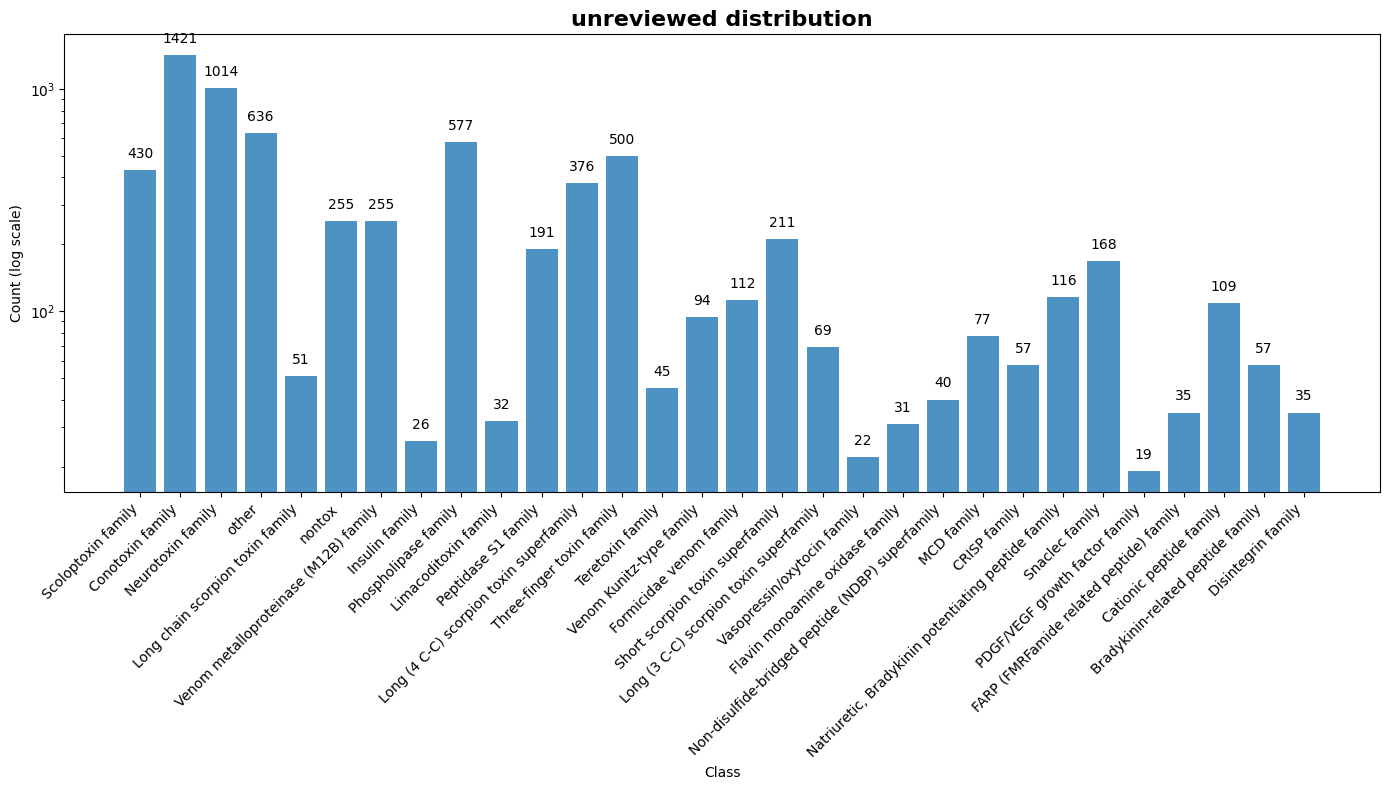

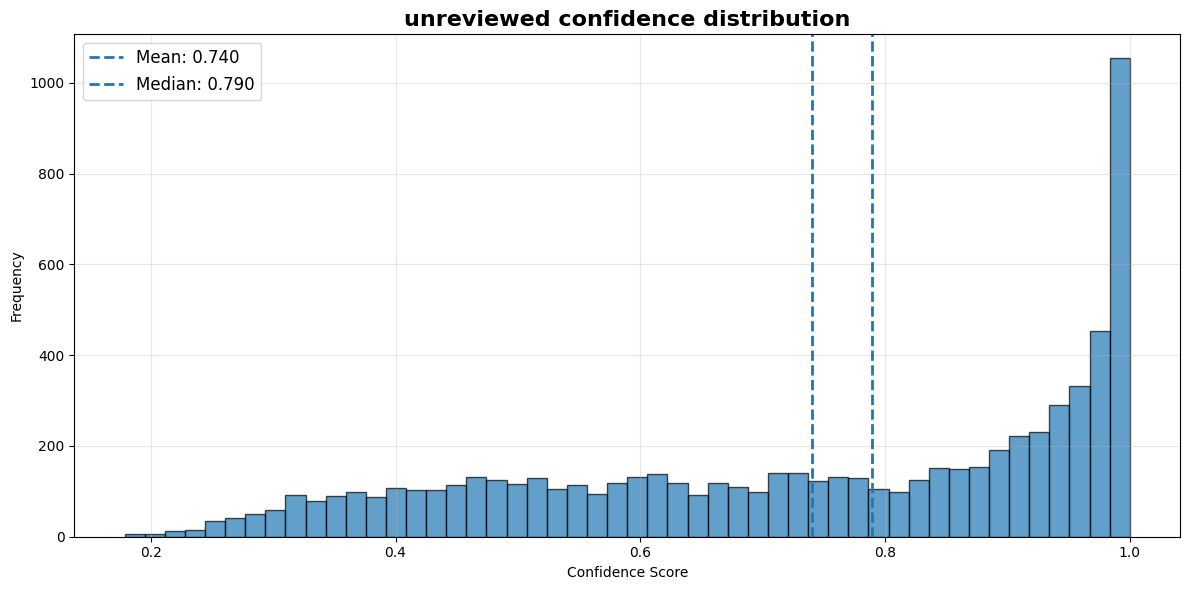

In [8]:
unreviewed_results = run_pipeline(
    loader=loader,
    model=model,
    device=DEVICE,
    label_encoder=label_encoder,
    name="unreviewed",
    show_plots=SHOW_PLOTS
)

df_unreviewed   = unreviewed_results["df"]
stats_unreviewed = unreviewed_results["stats"]


In [9]:
import re
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

# --- normalize to bare UniProt accession, e.g. "A0A068B6Q6"
ACC_RE = re.compile(r'^(?:[a-z]{2}\|)?([A-Z0-9]+)(?:\|.*)?$', re.IGNORECASE)
def norm_acc(x: str) -> str:
    s = str(x).strip()
    m = ACC_RE.match(s)
    acc = m.group(1) if m else s.split()[0]
    acc = acc.split('-')[0].split('.')[0]   # drop isoform/version
    return acc.upper()

pred_df = unreviewed_results["df"].rename(columns={"predicted_class": "prediction"}).copy()
pred_df["acc"] = pred_df["identifier"].map(norm_acc)

gt_df = kw_0800[["Entry","Protein families"]].copy()
gt_df["acc"] = gt_df["Entry"].map(norm_acc)
gt_df = gt_df.rename(columns={"Protein families":"actual"})

# --- merge on normalized accession
eval_df = pred_df.merge(gt_df[["acc","actual"]], on="acc", how="inner")
print("Matched rows:", len(eval_df), "of", len(pred_df))

# bail out early if still zero to debug a few examples
if len(eval_df) == 0:
    print("Sample preds:", pred_df["identifier"].head().tolist())
    print("Sample GT:", kw_0800["Entry"].head().tolist())
else:
    # metrics
    y_true = eval_df["actual"].astype(str).to_numpy()
    y_pred = eval_df["prediction"].astype(str).to_numpy()
    labels = sorted(set(y_true) | set(y_pred))

    acc = accuracy_score(y_true, y_pred)
    rep = classification_report(y_true, y_pred, labels=labels, zero_division=0, output_dict=True)
    cm  = confusion_matrix(y_true, y_pred, labels=labels)

    print(f"\n=== Evaluation vs kw_0800 (normalized accessions) ===")
    print(f"Samples evaluated: {len(eval_df):,}")
    print(f"Accuracy: {acc:.4f}")

    rep_df = pd.DataFrame(rep).T.reset_index().rename(columns={"index":"class"})
    per_class = rep_df[rep_df["class"].isin(labels)][["class","precision","recall","f1-score","support"]]\
                .sort_values("support", ascending=False)
    print("\nPer-class (sorted by support):")
    print(per_class.to_string(index=False, max_rows=200))


Matched rows: 7061 of 7061

=== Evaluation vs kw_0800 (normalized accessions) ===
Samples evaluated: 7,061
Accuracy: 0.7794

Per-class (sorted by support):
                                              class  precision   recall  f1-score  support
                                              other   0.665094 0.340032  0.450000   1244.0
                                   Conotoxin family   0.734694 0.920635  0.817221   1134.0
                                  Neurotoxin family   0.880671 0.877210  0.878937   1018.0
                               Phospholipase family   1.000000 0.902973  0.949013    639.0
                          Three-finger toxin family   1.000000 0.939850  0.968992    532.0
            Long (4 C-C) scorpion toxin superfamily   0.989362 0.885714  0.934673    420.0
              Venom metalloproteinase (M12B) family   0.952941 0.864769  0.906716    281.0
                   Short scorpion toxin superfamily   0.952607 0.750000  0.839248    268.0
                         

In [ ]:
cm